In [30]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from hydrosense.database.ades import GestionnairePiezometrie

### Téléchargement Piezo N° 2

Le Piézomètre de Référence de Saint-Fraigne

-Nouveau Code National BSS : BSS001RQQE
-Ancien Code BSS (Indice) : 06843X0019/P1
-Nom officiel dans les bases de données : ST-FRAIGNE (situé au lieu-dit Le Vivier)
-Masse d'eau / Aquifère : Calcaires du Jurassique supérieur du bassin de l'Aume

In [32]:
bss_id = 'BSS001RQQE' #saint-fraigne
#bss_id = 'BSS001QHYH'

gestionnaire = GestionnairePiezometrie(dossier_sortie="../raw_data")
print("ok")
gestionnaire.telecharger_bassin_versant([bss_id])

ok
--- Début du traitement pour 1 forages ---
Info: données BSS001RQQE déja présente
--- Traitement du bassin versant terminé ! ---


In [33]:
df = pd.read_csv(f'../raw_data/piezo_{bss_id}.csv', sep = ';')
# df = df.set_index('date_mesure')
df['date_mesure'] = pd.to_datetime(df['date_mesure'])

df.head()

,date_mesure,niveau_nappe_eau,profondeur_nappe
0,1993-07-21,76.86,22.57
1,1993-07-22,76.84,22.59
2,1993-07-23,76.78,22.65
3,1993-07-24,76.73,22.70
4,1993-07-25,76.71,22.72


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11477 entries, 0 to 11476
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date_mesure       11477 non-null  datetime64[ns]
 1   niveau_nappe_eau  11477 non-null  float64       
 2   profondeur_nappe  11477 non-null  float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 269.1 KB


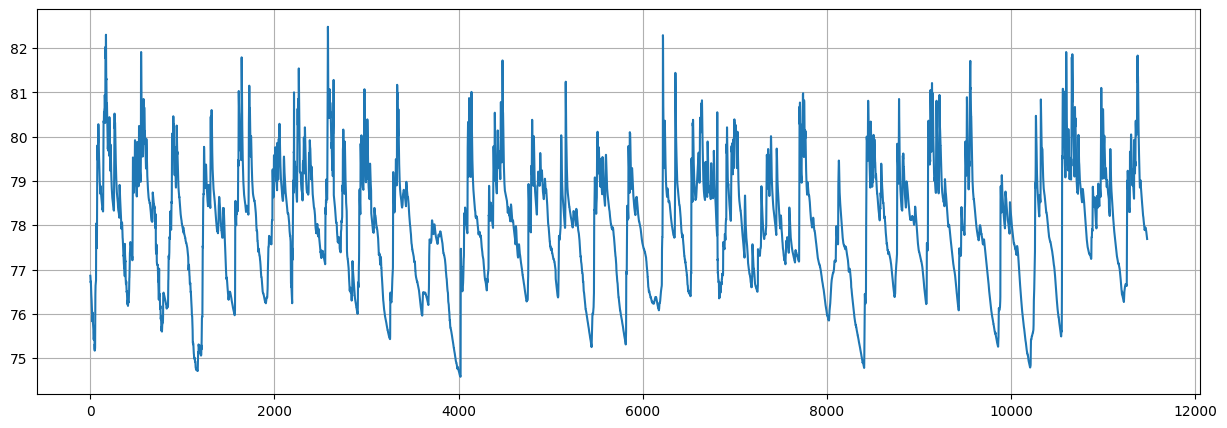

In [35]:
df['niveau_nappe_eau'].plot(kind = 'line', figsize=(15,5))
plt.grid(True)

In [36]:
df.shape

(11477, 3)

In [37]:
df.value_counts

<bound method DataFrame.value_counts of       date_mesure  niveau_nappe_eau  profondeur_nappe
0      1993-07-21             76.86             22.57
1      1993-07-22             76.84             22.59
2      1993-07-23             76.78             22.65
3      1993-07-24             76.73             22.70
4      1993-07-25             76.71             22.72
...           ...               ...               ...
11472  2026-05-26             77.77             21.66
11473  2026-05-27             77.75             21.68
11474  2026-05-28             77.73             21.70
11475  2026-05-29             77.71             21.72
11476  2026-05-30             77.69             21.74

[11477 rows x 3 columns]>

In [38]:
df['niveau_nappe_eau'].value_counts()

niveau_nappe_eau
78.63    57
78.75    52
77.73    49
78.89    48
78.72    47
         ..
74.62     1
74.60     1
81.40     1
81.72     1
81.36     1
Name: count, Length: 705, dtype: int64

In [39]:
df.isnull().sum().sort_values(ascending=False) / len(df)

date_mesure         0.0
niveau_nappe_eau    0.0
profondeur_nappe    0.0
dtype: float64

In [40]:
# Compter le total
total_nan = df['niveau_nappe_eau'].isna().sum()
print(f"Total de NaNs : {total_nan}")

# Calculer la taille des blocs de NaNs consécutifs
nan_groups = df['niveau_nappe_eau'].notna().cumsum()
trous_tailles = df['niveau_nappe_eau'].isna().groupby(nan_groups).sum()
print("\nDescription des tailles de trous (en lignes) :")
print(trous_tailles[trous_tailles > 0].describe())

Total de NaNs : 0

Description des tailles de trous (en lignes) :
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: niveau_nappe_eau, dtype: float64


In [41]:
total_nan = df['niveau_nappe_eau'].isna().sum()
pourcentage_nan = df['niveau_nappe_eau'].isna().mean() * 100

print(f"Nombre de NaNs : {total_nan}")
print(f"Pourcentage de NaNs : {pourcentage_nan:.2f}%")

Nombre de NaNs : 0
Pourcentage de NaNs : 0.00%


In [42]:
# 2. Créer le calendrier théorique parfait (sans aucun trou)
date_min = df['date_mesure'].min()
date_max = df['date_mesure'].max()
calendrier_parfait = pd.date_range(start=date_min, end=date_max, freq='D')

# 3. Trouver les dates du calendrier qui ne sont PAS dans ton dataframe
dates_absentes = calendrier_parfait.difference(df['date_mesure'])

print(f"Il y a {len(dates_absentes)} dates complètement absentes de ton fichier.")
if len(dates_absentes) > 0:
    print("Exemples de dates manquantes :")
    print(dates_absentes[:10]) # Affiche les 10 premières

Il y a 525 dates complètement absentes de ton fichier.
Exemples de dates manquantes :
DatetimeIndex(['1999-07-06', '1999-07-07', '1999-07-08', '1999-07-09',
               '1999-07-10', '1999-07-11', '1999-07-12', '1999-07-13',
               '1999-07-14', '1999-07-15'],
              dtype='datetime64[ns]', freq=None)


In [43]:
df.head()

,date_mesure,niveau_nappe_eau,profondeur_nappe
0,1993-07-21,76.86,22.57
1,1993-07-22,76.84,22.59
2,1993-07-23,76.78,22.65
3,1993-07-24,76.73,22.70
4,1993-07-25,76.71,22.72


In [44]:
dates_absentes

DatetimeIndex(['1999-07-06', '1999-07-07', '1999-07-08', '1999-07-09',
               '1999-07-10', '1999-07-11', '1999-07-12', '1999-07-13',
               '1999-07-14', '1999-07-15',
               ...
               '2024-02-15', '2024-02-16', '2024-02-17', '2024-02-18',
               '2025-04-04', '2025-04-05', '2025-04-06', '2025-04-07',
               '2025-04-08', '2025-04-09'],
              dtype='datetime64[ns]', length=525, freq=None)

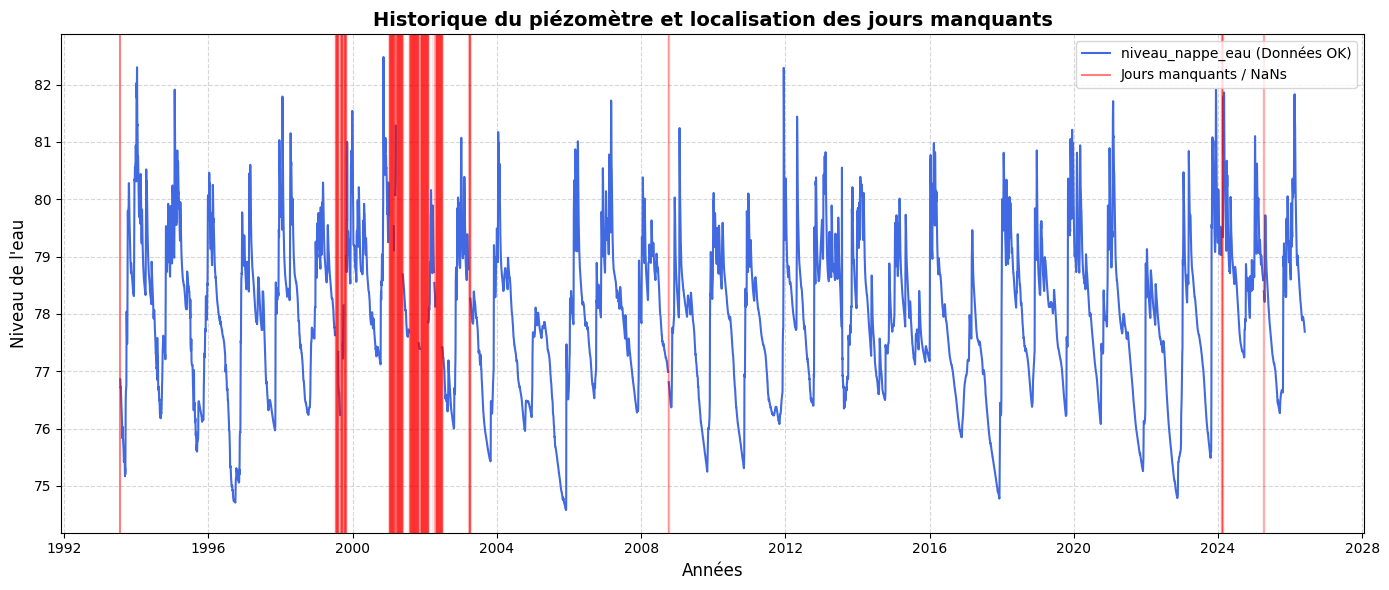

In [45]:
# Cela va forcer les dates manquantes à devenir des lignes physiques remplies de NaNs
df_complet = df.set_index('date_mesure').reindex(calendrier_parfait)

#Tracer le graphique
plt.figure(figsize=(14, 6))

# En bleu : Le niveau de la nappe (les données que tu possèdes)
plt.plot(df_complet.index, df_complet['niveau_nappe_eau'],
         color='royalblue', label='niveau_nappe_eau (Données OK)', linewidth=1.5)

# En rouge : On affiche de grands traits verticaux là où il n'y a AUCUNE donnée
# (cumul des NaNs d'origine et des dates qui étaient absentes)
manques = df_complet['niveau_nappe_eau'].isna()
for date_manquante in df_complet[manques].index:
    plt.axvline(x=date_manquante, color='red', alpha=0.1, linestyle='-', linewidth=1)

# Hack pour afficher une seule légende "Données manquantes" pour les lignes rouges
plt.axvline(x=df_complet.index[0], color='red', alpha=0.5, label='Jours manquants / NaNs')

# Personnalisation du graphique
plt.title("Historique du piézomètre et localisation des jours manquants", fontsize=14, fontweight='bold')
plt.xlabel("Années", fontsize=12)
plt.ylabel("Niveau de l'eau", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

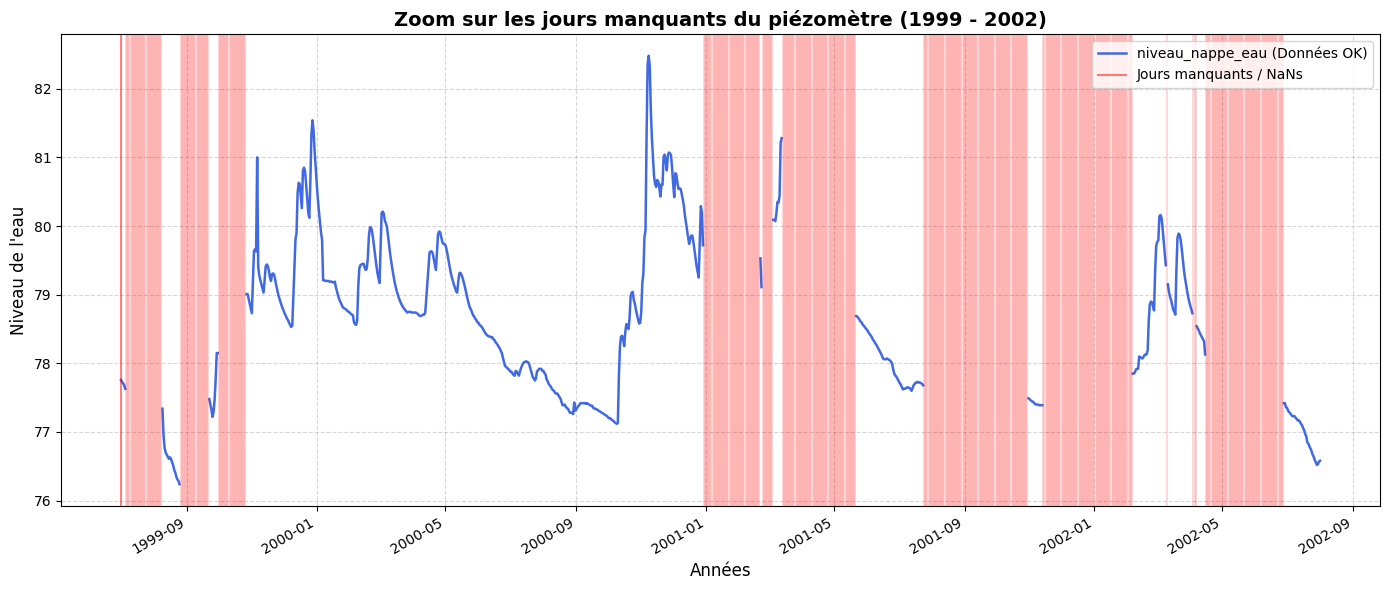

In [46]:
df_zoom = df_complet.loc['1999-07-01':'2002-08-01']

# Tracer le graphique zoomé
plt.figure(figsize=(14, 6))

# Courbe bleue : les données existantes sur cette période
plt.plot(df_zoom.index, df_zoom['niveau_nappe_eau'],
         color='royalblue', label='niveau_nappe_eau (Données OK)', linewidth=1.8)

# Barres rouges : localisation des NaNs et dates absentes entre 86 et 93
manques_zoom = df_zoom['niveau_nappe_eau'].isna()
for date_manquante in df_zoom[manques_zoom].index:
    plt.axvline(x=date_manquante, color='red', alpha=0.15, linestyle='-', linewidth=1.5)

# Ligne rouge invisible juste pour générer la légende proprement
plt.axvline(x=df_zoom.index[0], color='red', alpha=0.5, label='Jours manquants / NaNs')

# Personnalisation du rendu
plt.title("Zoom sur les jours manquants du piézomètre (1999 - 2002)", fontsize=14, fontweight='bold')
plt.xlabel("Années", fontsize=12)
plt.ylabel("Niveau de l'eau", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

# Amélioration de l'affichage des dates sur l'axe X
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

In [47]:

jours_manquants = manques_zoom.sum()

print(f"Il manque {jours_manquants} jours de relevé sur cette période.")

Il manque 478 jours de relevé sur cette période.


ON démarre donc en Aout 2002

In [48]:

# 2. On applique le filtre sur la colonne directement
df_lebest = df[
    (df['date_mesure'] >= '2002-08-01') &
    (df['date_mesure'] <= df['date_mesure'].max())
]

# 3. On affiche les premières lignes
df_lebest.head()

,date_mesure,niveau_nappe_eau,profondeur_nappe
2820,2002-08-01,76.58,22.85
2821,2002-08-02,76.59,22.84
2822,2002-08-03,76.59,22.84
2823,2002-08-04,76.59,22.84
2824,2002-08-05,76.59,22.84


In [49]:
# 1. On réinitialise l'index à 0 et on supprime l'ancienne colonne d'index (drop=True)
df_lebest = df_lebest.reset_index(drop=True)

# On vérifie le résultat
df_lebest.head()

,date_mesure,niveau_nappe_eau,profondeur_nappe
0,2002-08-01,76.58,22.85
1,2002-08-02,76.59,22.84
2,2002-08-03,76.59,22.84
3,2002-08-04,76.59,22.84
4,2002-08-05,76.59,22.84


<Axes: xlabel='date_mesure'>

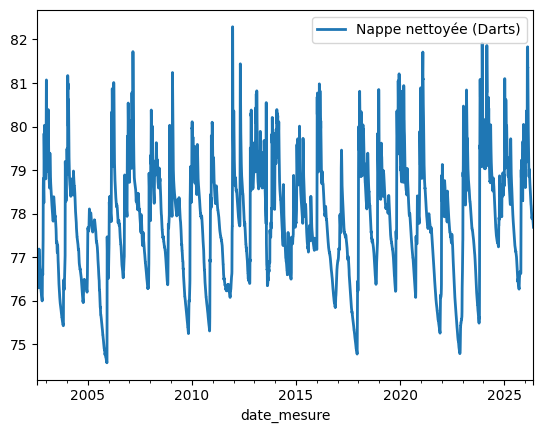

In [50]:
from darts.dataprocessing.transformers import MissingValuesFiller
from darts import TimeSeries

series = TimeSeries.from_dataframe(
    df_lebest,
    time_col='date_mesure',
    value_cols='niveau_nappe_eau',
    fill_missing_dates=True,
    freq='D'
)

# Initialiser le remplisseur (par défaut, il fait une interpolation linéaire)
filler = MissingValuesFiller()

# Créer une série complètement propre, sans aucun NaN
series_clean = filler.transform(series)

# Tu peux vérifier le résultat graphique
series_clean.plot(label="Nappe nettoyée (Darts)")

In [51]:
series_clean.dtype

dtype('float64')

In [52]:
series_clean.head(20)

,niveau_nappe_eau
date_mesure,
2002-08-01,76.58
2002-08-02,76.59
2002-08-03,76.59
2002-08-04,76.59
2002-08-05,76.59
...,...
2002-08-16,76.41
2002-08-17,76.38
2002-08-18,76.35


In [53]:
import os

In [54]:
# L'index du DataFrame sera ta colonne temporelle ('date_mesure')
df_processed = series_clean.to_dataframe()

# Optionnel : Si tu veux que 'date_mesure' redevienne une colonne normale et pas l'index (recommandé pour BigQuery)
df_processed = df_processed.reset_index()

# ==========================================
# EXPORT 1 : VERS UN FICHIER CSV
# ==========================================
df_processed.to_csv("./data/piezo_saint_fraigne_clean.csv", index=False)
